<a href="https://colab.research.google.com/github/Oksana0020/perfumes/blob/main/Project3_DataDrivenModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Allocation of marks**

Stages 1,2,3   Total 30%

Ideally your dataset will not need a lot of work. Marks going for the choosing,  training, evaluation and refining of model primarily




---



Stage 4,5       Total 60%

Choose your model

https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html


Train and evaluate your model. Refine the model or choose another estimator or approach?

Do not overwrite cells and add commentry between iterations.



---




Stage 6         Total 10%

Perfume Recognition from Image, train CNN on images
evaluate CNN using Accuracy,Confusion matrix - if images will be found

1)Look up perfume in fragrance dataset, return top,middle,base notes, offer similar within different price range
find similar perfumes

2)look for Clustering (unsupervised learning)

KNN (nearest neighbours)

(optionally) similarity metrics (Jaccard / cosine)



Input: perfume name

-return notes (top/middle/base)

-convert to vector and find similar perfumes (KNN)

-allow filtering by price range

-show recommendations of other parfumes within price range

what goes in x
what goes out y

# **Stage 1**
***Describe Data***

*A brief description of the data, where you sourced it, headers of the data. Summary statistics, charts etc...*

*If you using data from different sources how you might link them.*

This project uses two datasets from Kaggle:

**Dataset 1 Fragrantica Fragrance Dataset**

Source:
https://www.kaggle.com/datasets/olgagmiufana1/fragrantica-com-fragrance-dataset

This dataset contains detailed information about perfumes, including their fragrance compositions (top, middle and base notes), along with additional attributes such as accords and ratings. It is used as the primary dataset for modelling perfume similarity.

**Dataset 2 Perfume E-Commerce Dataset**

Source
https://www.kaggle.com/datasets/kanchana1990/perfume-e-commerce-dataset-2024

This dataset contains perfume listings from an e-commerce platform, including product names, brands and price information. It is used to add price-based filtering to the recommendation system.

**For clustering:**

X = vectorised perfume composition (top,middle,base notes)

y = not applicable (unsupervised learning)

Output = cluster labels representing fragrance categories

**for CNN if to train on pictures:**

X = perfume images  
y = perfume name

If unsupervised learning techniques are used, there is no explicit target variable (y).

The input features (X) consist of perfume compositions, including top, middle and base notes, which are converted into vector representations.

A K-Nearest Neighbours (KNN) approach will be used to find similar perfumes based on these features. Additionally, clustering techniques will applied to group perfumes into categories

Some examples of possible categories:fresh, woody, spicy, musky, floral, fruity, oriental, citrus,sweet,balzamic, syntetic, vanilla, leather, tobacco, powdery, metallic etc.

These categories are not predefined labels in datasets but will be derived from patterns discovered in the data.

In order to link two datasets, text preprocessing should be applied including:
- converting to lowercase
- removing special characters
- standardising perfume names

I will link datasets using the brand and perfume name fields.
df_fragrance has "Perfume", "Brand"
df_price has "title", "brand"

Matching on full perfume name would be hard because titles contain extra words (ml, EDT, spray, etc.) So due to inconsistencies in product titles, a brand-based merge should be used as primary linking method.

Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
os.listdir("/content/drive/MyDrive/Colab Notebooks/Project 3/")

['Project3. DataDrivenModel.ipynb',
 'fragrantica.csv',
 'perfume_ecommerce_women.csv',
 'perfume_ecommerce_men.csv']

In [5]:
path = "/content/drive/MyDrive/Colab Notebooks/Project 3/"

In [6]:
df_price_men = pd.read_csv(path + "perfume_ecommerce_men.csv", encoding="utf-8")
df_price_women = pd.read_csv(path + "perfume_ecommerce_women.csv", encoding="utf-8")
df_fragrance = pd.read_csv(path + "fragrantica.csv",sep=";",encoding="latin1")

In [7]:
df_price = pd.concat([df_price_men, df_price_women], ignore_index=True)

Preview

In [8]:
df_fragrance.head()

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,"1,42",201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,"1,86",70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,"1,91",285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,"1,92",59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,"1,93",632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [ ]:
df_price.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


Names of columns

In [ ]:
print(df_fragrance.columns.tolist())

['url', 'Perfume', 'Brand', 'Country', 'Gender', 'Rating Value', 'Rating Count', 'Year', 'Top', 'Middle', 'Base', 'Perfumer1', 'Perfumer2', 'mainaccord1', 'mainaccord2', 'mainaccord3', 'mainaccord4', 'mainaccord5']


In [ ]:
print(df_price.columns.tolist())

['brand', 'title', 'type', 'price', 'priceWithCurrency', 'available', 'availableText', 'sold', 'lastUpdated', 'itemLocation']


Info

In [ ]:
df_fragrance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           24063 non-null  object 
 1   Perfume       24063 non-null  object 
 2   Brand         24063 non-null  object 
 3   Country       24063 non-null  object 
 4   Gender        24063 non-null  object 
 5   Rating Value  24063 non-null  object 
 6   Rating Count  24063 non-null  int64  
 7   Year          22026 non-null  float64
 8   Top           24063 non-null  object 
 9   Middle        24063 non-null  object 
 10  Base          24063 non-null  object 
 11  Perfumer1     24063 non-null  object 
 12  Perfumer2     1336 non-null   object 
 13  mainaccord1   24063 non-null  object 
 14  mainaccord2   24050 non-null  object 
 15  mainaccord3   23949 non-null  object 
 16  mainaccord4   23675 non-null  object 
 17  mainaccord5   23082 non-null  object 
dtypes: float64(1), int64(1), o

In [ ]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1998 non-null   object 
 1   title              2000 non-null   object 
 2   type               1995 non-null   object 
 3   price              2000 non-null   float64
 4   priceWithCurrency  2000 non-null   object 
 5   available          1758 non-null   float64
 6   availableText      1989 non-null   object 
 7   sold               1978 non-null   float64
 8   lastUpdated        1874 non-null   object 
 9   itemLocation       2000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 156.4+ KB


In [ ]:
df_fragrance.describe(include="all")

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
count,24063,24063,24063,24063,24063,24063,24063.000000,22026.000000,24063,24063,24063,24063,1336,24063,24050,23949,23675,23082
unique,24063,22840,1060,54,3,221,NaN,NaN,18771,19690,16393,869,259,66,71,72,69,77
top,https://www.fragrantica.com/perfume/nilafar-du...,vetiver,avon,France,women,4,NaN,NaN,bergamot,jasmine,musk,unknown,verônica kato,citrus,woody,woody,woody,woody
freq,1,18,578,7261,11376,504,NaN,NaN,304,162,319,12320,62,3320,2748,2507,2212,1912
mean,NaN,NaN,NaN,NaN,NaN,NaN,501.396542,2012.455961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1429.484690,13.526737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,1781.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,127.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,360.000000,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_price.describe(include="all")

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: FutureWarning: Parsed string "May 24, 2024 10:26:59 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
count,1998,2000,1995,2000.000000,2000,1758.000000,1989,1978.000000,1874,2000
unique,401,1941,116,NaN,1164,NaN,1300,NaN,1831,447
top,Giorgio Armani,Idole by Lancome Eau de Parfum EDP Perfume for...,Eau de Parfum,NaN,US $29.99/ea,NaN,More than 10 available / 12 sold,NaN,"May 24, 2024 10:26:59 PDT","Dallas, Texas, United States"
freq,72,4,847,NaN,38,NaN,12,NaN,5,267
mean,NaN,NaN,NaN,43.187090,NaN,20.728669,NaN,632.473711,NaN,NaN
std,NaN,NaN,NaN,32.619625,NaN,56.781389,NaN,2470.055822,NaN,NaN
min,NaN,NaN,NaN,1.990000,NaN,2.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,21.972500,NaN,5.000000,NaN,14.000000,NaN,NaN
50%,NaN,NaN,NaN,34.040000,NaN,10.000000,NaN,51.000000,NaN,NaN
75%,NaN,NaN,NaN,53.990000,NaN,10.000000,NaN,285.750000,NaN,NaN


##Charts

##Fragrance Dataset

Top 10 Brands

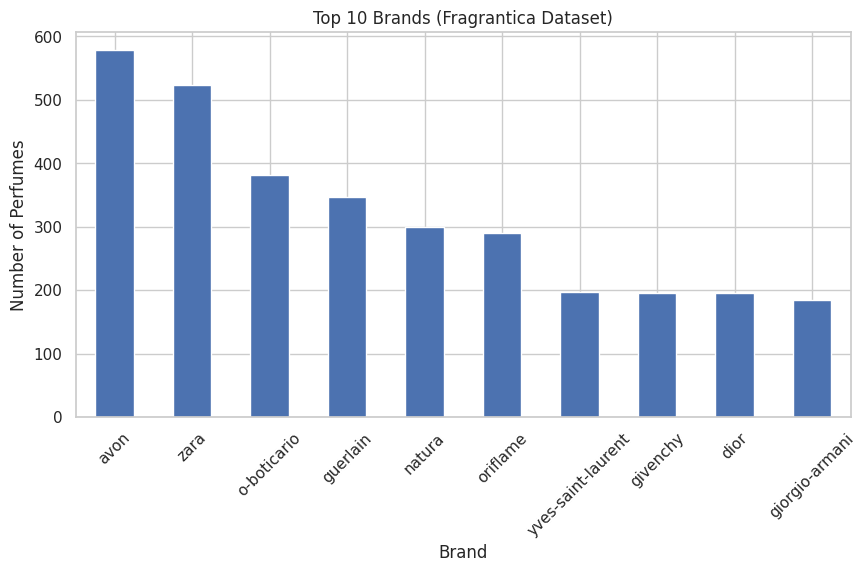

In [ ]:
plt.figure(figsize=(10,5))
df_fragrance["Brand"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands (Fragrantica Dataset)")
plt.xlabel("Brand")
plt.ylabel("Number of Perfumes")
plt.xticks(rotation=45)
plt.show()

Most Common Top Notes

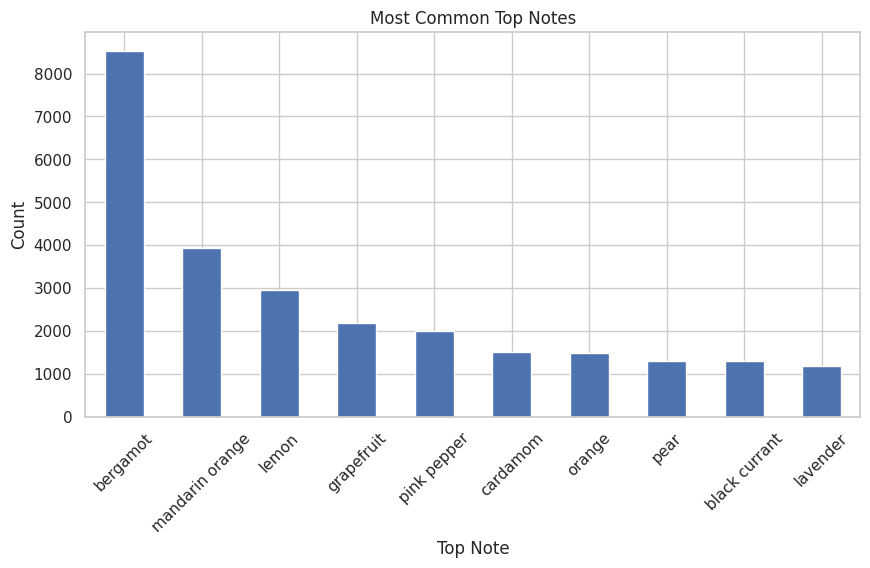

In [ ]:
top_notes = df_fragrance["Top"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
top_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Top Notes")
plt.xlabel("Top Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Most Common Middle Notes

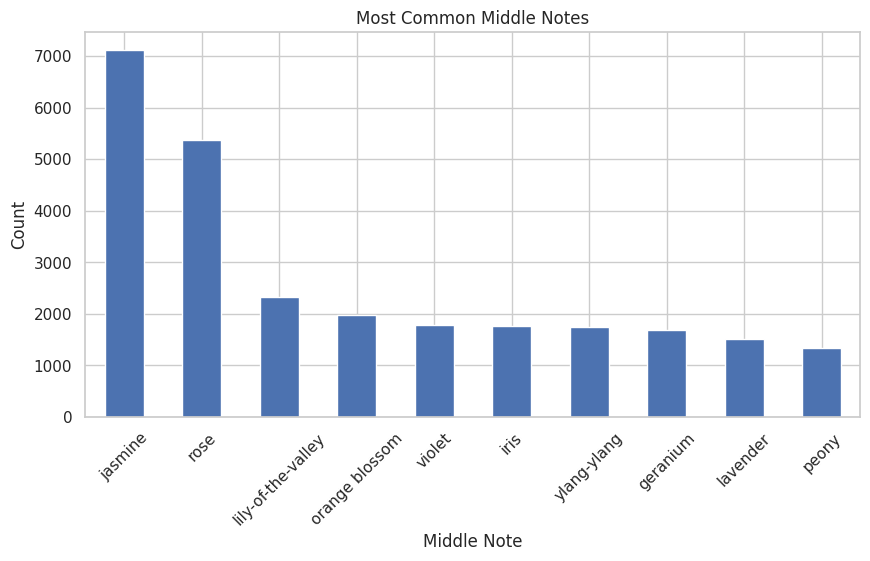

In [ ]:
middle_notes = df_fragrance["Middle"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
middle_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Middle Notes")
plt.xlabel("Middle Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Most Common Base Notes

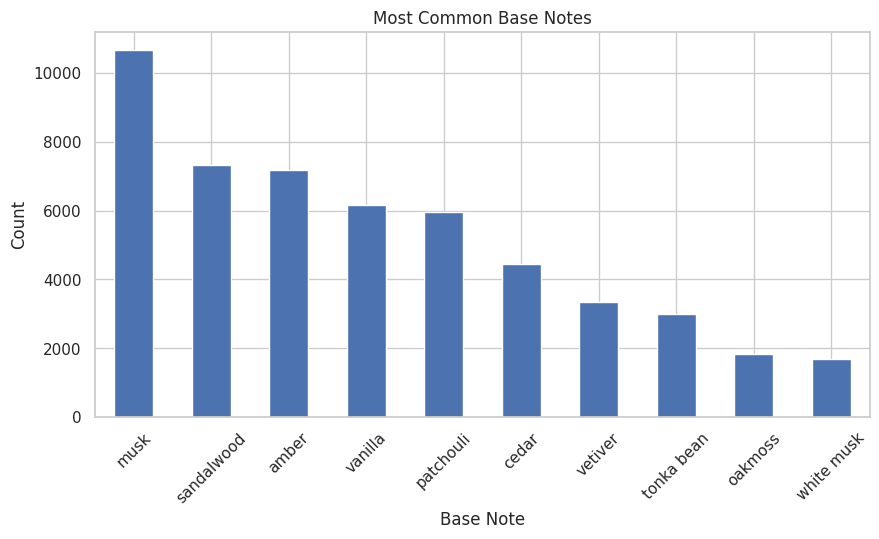

In [ ]:
base_notes = df_fragrance["Base"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
base_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Base Notes")
plt.xlabel("Base Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Gender Distribution

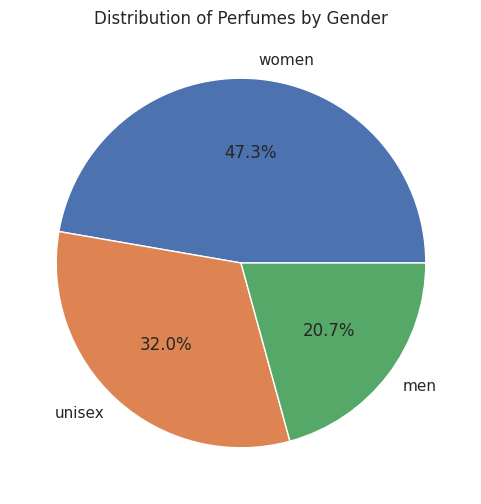

In [ ]:
plt.figure(figsize=(6,6))
df_fragrance["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Perfumes by Gender")
plt.ylabel("")
plt.show()

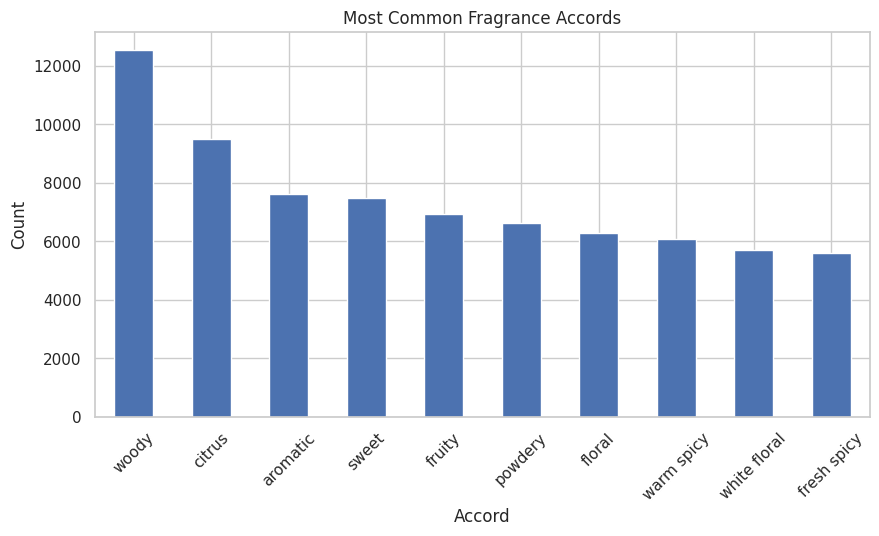

In [ ]:
accords = pd.concat([
    df_fragrance["mainaccord1"],
    df_fragrance["mainaccord2"],
    df_fragrance["mainaccord3"],
    df_fragrance["mainaccord4"],
    df_fragrance["mainaccord5"]
])

plt.figure(figsize=(10,5))
accords.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Fragrance Accords")
plt.xlabel("Accord")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Prcies from 2nd dataset

In [ ]:
df_price["price_clean"] = (
    df_price["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)
df_price["price_clean"] = pd.to_numeric(df_price["price_clean"], errors="coerce")

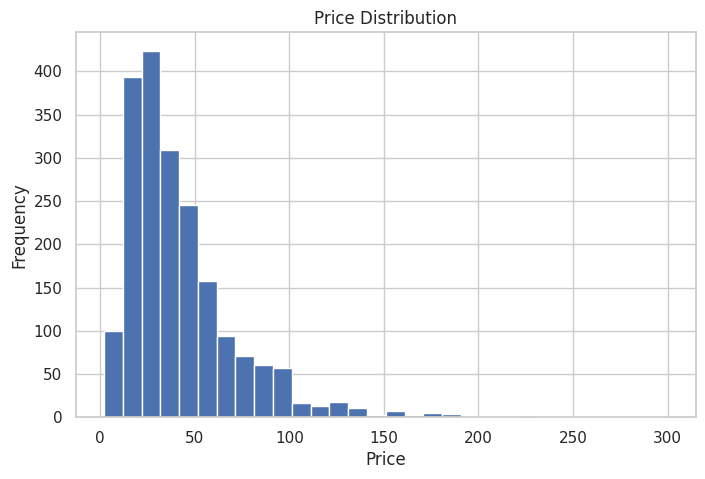

In [ ]:
plt.figure(figsize=(8,5))
df_price["price_clean"].dropna().hist(bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Brand distribution in second dataset.

Some brands dominate the dataset, indicating uneven representation of products.

<Axes: xlabel='brand'>

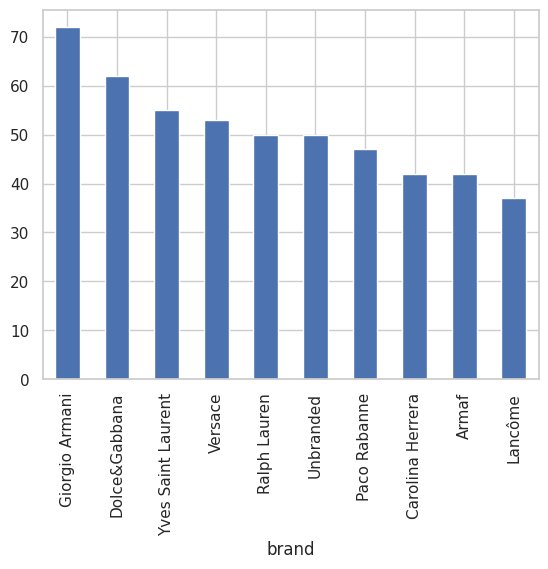

In [ ]:
df_price["brand"].value_counts().head(10).plot(kind="bar")

Price by Type

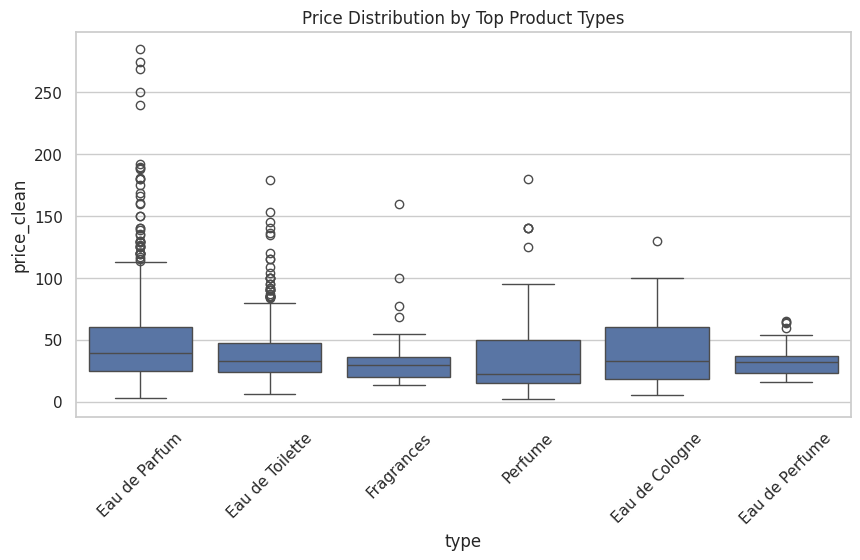

In [ ]:
top_types = df_price["type"].value_counts().head(6).index

plt.figure(figsize=(10,5))
sns.boxplot(
    x="type",
    y="price_clean",
    data=df_price[df_price["type"].isin(top_types)]
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Top Product Types")
plt.show()

Price distribution by brand

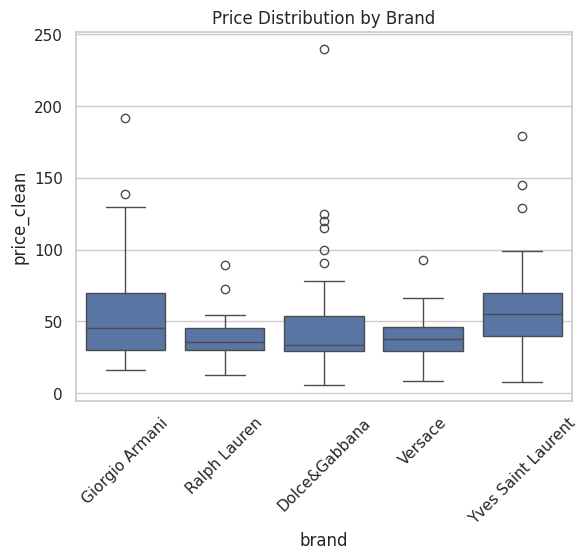

In [ ]:
top_brands = df_price["brand"].value_counts().head(5).index

sns.boxplot(
    x="brand",
    y="price_clean",
    data=df_price[df_price["brand"].isin(top_brands)]
)
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")
plt.show()

# **Stage 2**

*Justification for the property that you would like the model to predict.*

I want to model similarity between perfumes based on their fragrance composition.

Since perfumes are described using top, middle and base notes, these features will be used as the input representation.

Unsupervised learning methods such as clustering and nearest neighbour search will be applied to group similar perfumes and recommend alternatives.

Question

Can perfume similarity be modeled using top, middle and base notes, and can those recommendations be filtered by price range?

# **Stage 3**

*Cleaning the data, linking datasets, preparing features.*



Creating working copies and clean price column

In [18]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer

fragrance = df_fragrance.copy()
price_data = df_price.copy()
price_data["price_clean"] = (
    price_data["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True))
price_data["price_clean"] = pd.to_numeric(price_data["price_clean"], errors="coerce")

Standardize text fields

In [19]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

fragrance["perfume_clean"] = fragrance["Perfume"].apply(clean_text)
fragrance["brand_clean"] = fragrance["Brand"].apply(clean_text)
price_data["title_clean"] = price_data["title"].apply(clean_text)
price_data["brand_clean"] = price_data["brand"].apply(clean_text)
price_data["type_clean"] = price_data["type"].apply(clean_text)

Clean note columns, combine notes into one feature

In [20]:
for col in ["Top", "Middle", "Base"]:
    fragrance[col] = fragrance[col].fillna("").astype(str).str.lower().str.strip()

fragrance["all_notes"] = (
    fragrance["Top"] + ", " +
    fragrance["Middle"] + ", " +
    fragrance["Base"])

fragrance["all_notes"] = fragrance["all_notes"].apply(clean_text)

Drop rows with no note information, Create link keys, First merge by brand

In [21]:
fragrance = fragrance[fragrance["all_notes"].str.strip() != ""].copy()

merged = pd.merge(
    fragrance,
    price_data,
    on="brand_clean",
    how="left",
    suffixes=("_frag", "_price"))

Keeping likely title matches

perfume name should appear inside title

In [28]:
merged["possible_match"] = merged.apply(
    lambda row: row["perfume_clean"] in row["title_clean"] if pd.notna(row["title_clean"]) else False,
    axis=1)
df_model = merged[merged["possible_match"] == True].copy()
df_model = df_model.reset_index(drop=True)

print("Fragrance dataset shape:", fragrance.shape)
print("Price dataset shape:", price_data.shape)
print("Merged dataset shape:", df_model.shape)
print("Filtered linked dataset shape:", df_model.shape)


Fragrance dataset shape: (24063, 21)
Price dataset shape: (2000, 14)
Merged dataset shape: (2701, 35)
Filtered linked dataset shape: (2701, 35)


vectorization of notes

TF-IDF (Term Frequency-Inverse Document Frequency)

https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

https://medium.com/@ashwinkumar577/countvectorizer-and-tfidfvectorizer-for-beginner-ac81afef30aa

In [29]:
vectorizer = TfidfVectorizer()
X_notes = vectorizer.fit_transform(fragrance["all_notes"])

print("TF-IDF matrix shape:", X_notes.shape)

TF-IDF matrix shape: (24063, 1254)


view cleaned data

In [30]:
display(fragrance[["Perfume", "Brand", "Top", "Middle", "Base", "all_notes"]].head())
display(price_data[["brand", "title", "type", "price", "price_clean"]].head())
display(df_model[["Perfume", "Brand", "title", "brand", "type", "price_clean"]].head())

,Perfume,Brand,Top,Middle,Base,all_notes
0,accento-overdose-pride-edition,xerjoff,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",fruity notes aldehydes green notes bulgarian r...
1,classique-pride-2024,jean-paul-gaultier,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",yuzu citruses orange blossom neroli musk blond...
2,classique-pride-2023,jean-paul-gaultier,"blood orange, yuzu","neroli, orange blossom","musk, white woods",blood orange yuzu neroli orange blossom musk w...
3,pride-edition-man,bruno-banani,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",guarana grapefruit red apple walnut lavender g...
4,le-male-pride-collector,jean-paul-gaultier,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",mint lavender cardamom artemisia bergamot cara...


,brand,title,type,price,price_clean
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,84.99
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,109.99
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,100.00
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,44.99
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,16.91


,Perfume,Brand,title,brand,type,price_clean
0,1-million,paco-rabanne,1 Million by Paco Rabanne 3.4 Fl oz / 100 ml P...,Paco Rabanne,PARFUM,68.99
1,1-million,paco-rabanne,1 Million Paco Rabanne Men 3.4 oz EDT Spray,Paco Rabanne,Eau de Toilette,49.99
2,1-million,paco-rabanne,1 Million Paco Rabanne Men 3.4 oz EDT Spray *F...,Paco Rabanne,Eau de Toilette,49.96
3,1-million,paco-rabanne,Paco Rabanne 1 Million Men's Fragrance EDT Col...,Paco Rabanne,Eau de Toilette,49.99
4,1-million,paco-rabanne,1 Million by Paco Rabanne 3.4 oz EDT Cologne f...,Paco Rabanne,Eau de Toilette,47.99


In this stage, the datasets were cleaned and prepared for modelling.
Fragrance dataset was processed by combining the top, middle and base notes into a single text feature representing each perfume.
This text was then transformed into a numerical representation using TF-IDF vectorization. This allows similarity between perfumes to be computed.

The pricing dataset was cleaned by converting price values into a consistent numeric format.
Text fields in both datasets were standardised by converting them to lowercase, removing punctuation and normalising spacing.

Two datasets were linked using both brand and perfume name. This approach reduces incorrect matches that could occur if only brand or title used.

Additionally, product type was considered, as items such as deodorants or body sprays may have significantly different price ranges compared to perfumes. This ensures that price comparisons and recommendations remain meaningful.

# **Stage 4**
*Choose and train Estimator.*

In this stage, K-Nearest Neighbours model will be used to identify similar perfumes based on vectorss representations of fragrance notes. Additionally, KMeans clustering will be applied to group perfumes into categories based on scent similarity.

1)KNN Use TF-IDF vectors → find similar perfumes

Input Perfume → vector (notes)

Output Name of Closest perfumes (based on similar scents)

2)Clustering

Group perfumes into categories

Cluster 0 → citrus/fresh  
Cluster 1 → woody  
Cluster 2 → sweet

# **Stage 5**
*Evaluate your model and revisit 4...repeat..*

Since the model is unsupervised, evaluation will be based on the quality of recommendations, distance scores and clustering evaluation.

Improving: Try different K, Try different K(Top only vs Top+Middle+Base), Filter by type (Only perfumes, not deodorants)

# **Stage 6**
***Present results and Conclusions***



examples of recommended parfumes, clusters, price filtering,conclusions